# 19 — Aggregate sensitivities within each bucket

Calculate the bucket capital amount Kb from weighted sensitivities.

Kb combines factors using within-bucket correlation rho. The initial Sb is the uncapped signed sum used across buckets. Only if the across-bucket radicand becomes negative is the alternative capped Sb between minus Kb and plus Kb applied. For GIRR, inflation-to-yield correlation is 40%; cross-currency basis has 0% correlation with yield, inflation and other basis curves.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from IPython.display import display
from frtb_engine.notebook_tools import (
    INR_CRORE, bar_crore, bar_inr, configure_notebooks, crore_table,
    draw_capital_map, draw_flow, heatmap, percent_columns,
)

configure_notebooks()
ROOT = Path.cwd()
if not (ROOT / 'outputs').exists():
    ROOT = ROOT.parent
RUN_ID = (ROOT / 'outputs/latest_run.txt').read_text(encoding='utf-8').strip()
RUN = ROOT / 'outputs' / RUN_ID
print(f'Calculation run used in this notebook: {RUN_ID}')

Calculation run used in this notebook: SA_20260901T122303Z


This is the part of the calculation chain being handled here:

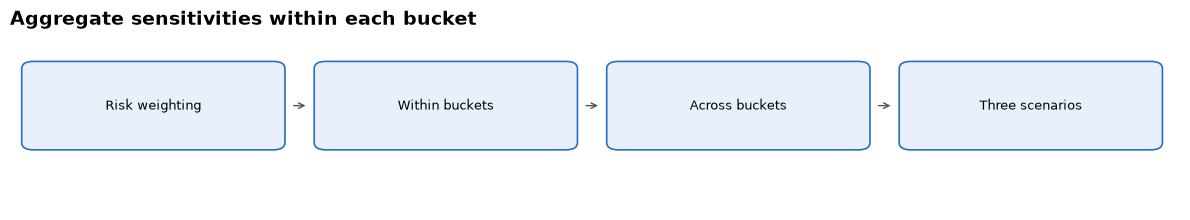

In [2]:
draw_flow(['Risk weighting', 'Within buckets', 'Across buckets', 'Three scenarios'],'Aggregate sensitivities within each bucket',wrap_after=4)

Add squared weighted sensitivities and every correlated pair contribution, then take the square root.

$$K_b=\sqrt{\sum_kWS_k^2+\sum_k\sum_{l
e k}\rho_{kl}WS_kWS_l}$$

$$S_b=\sum_kWS_k;\quad S_b^{alt}=\max[-K_b,\min(S_b,K_b)]\text{ only when required}$$

In [3]:
from frtb_engine.parameters import within_bucket_correlation
weighted=pd.read_csv(RUN/'06_delta_netted_weighted.csv')
girr=weighted[weighted.risk_class=='GIRR']
groups=girr.groupby(['risk_class','bucket']).size().sort_values(ascending=False)
risk_class,bucket=groups[groups>=2].index[0]
sample=weighted[(weighted.risk_class==risk_class)&(weighted.bucket.astype(str)==str(bucket))].copy()
records=sample.to_dict('records'); matrix=np.eye(len(records))
for i,left in enumerate(records):
    for j,right in enumerate(records):
        if i!=j: matrix[i,j]=within_bucket_correlation(left,right,'medium')
corr=pd.DataFrame(matrix,index=sample.risk_factor_id,columns=sample.risk_factor_id)
variance=sum(row['weighted_sensitivity']**2 for row in records)
for i,left in enumerate(records):
    for right in records[i+1:]:
        variance+=2*within_bucket_correlation(left,right,'medium')*left['weighted_sensitivity']*right['weighted_sensitivity']
kb=np.sqrt(max(variance,0)); sb=max(min(sample.weighted_sensitivity.sum(),kb),-kb)
sample['tenor_display']=sample.apply(
    lambda row:f"{row.tenor:g} years" if row.factor_type=='standard'
    else 'Not applicable — flat factor',axis=1)
display(crore_table(sample[['risk_factor_id','factor_type','tenor_display','weighted_sensitivity']],['weighted_sensitivity']))
print(f'Selected bucket: {risk_class} / {bucket}')
print(f'Kb = INR {kb/INR_CRORE:,.4f} crore')
print(f'Sb = INR {sb/INR_CRORE:,.4f} crore')

,risk_factor_id,factor_type,tenor_display,Weighted Sensitivity (INR crore)
31,INR_INFLATION,inflation,Not applicable — flat factor,1.4979
32,INR_OIS_0.25Y,standard,0.25 years,0.1198
33,INR_OIS_0.5Y,standard,0.5 years,0.2983
34,INR_OIS_1.0Y,standard,1 years,-0.3387
35,INR_OIS_10.0Y,standard,10 years,0.1307
36,INR_OIS_2.0Y,standard,2 years,-0.2510
37,INR_OIS_3.0Y,standard,3 years,-0.1415
38,INR_OIS_5.0Y,standard,5 years,-1.7429
39,INR_OVER_USD_BASIS,cross_currency_basis,Not applicable — flat factor,1.0565


Selected bucket: GIRR / INR
Kb = INR 2.2454 crore
Sb = INR 0.6290 crore


The visual below uses the calculated rows shown above.

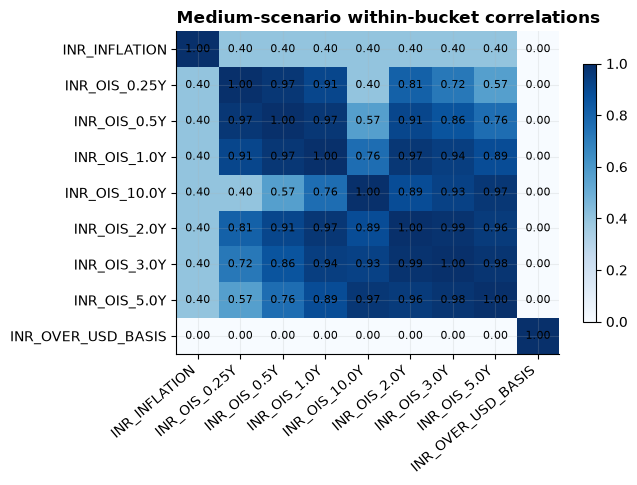

In [4]:
heatmap(corr,'Medium-scenario within-bucket correlations',value_format='.2f')

Each bucket is now represented by Kb and Sb rather than many factor rows.